# Biscione & Bowers (2021) Cosine-Similarity Invariance Metric

## 0. Setup


In [12]:
import glob
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image, ImageDraw, ImageFilter
from torchvision import models
from torchvision.transforms import functional as TF
from tqdm import tqdm

RANDOM_STATE = 42
IMG_SIZE = 32
BACKGROUND_GRAY = 0.5
BATCH_SIZE = 64
DATA_ROOT = Path("../dataset/coco_crops_transparent_8cat")

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

IMAGENET_MEAN = models.VGG16_Weights.IMAGENET1K_V1.transforms().mean
IMAGENET_STD = models.VGG16_Weights.IMAGENET1K_V1.transforms().std


class PlainVGGFeatureExtractor(nn.Module):
    """VGG-16 features through layer 30 (inclusive) - 1x1x512 output at 32x32 input."""

    def __init__(self):
        super().__init__()
        weights = models.VGG16_Weights.IMAGENET1K_V1
        vgg = models.vgg16(weights=weights)
        self.features = nn.Sequential(*list(vgg.features.children())[:31])
        for p in self.parameters():
            p.requires_grad = False
        self.eval()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.features(x)


feature_extractor = PlainVGGFeatureExtractor().to(device)
vgg_layers = list(feature_extractor.features.children())
print(feature_extractor)


Using device: mps
PlainVGGFeatureExtractor(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_

In [13]:
def apply_circular_aperture(img: Image.Image, background_gray: float) -> Image.Image:
    """Mask everything outside the image's inscribed circle to the gray background."""
    w, h = img.size
    radius = min(w, h) // 2
    cx, cy = w // 2, h // 2
    mask = Image.new("L", (w, h), 0)
    ImageDraw.Draw(mask).ellipse((cx - radius, cy - radius, cx + radius, cy + radius), fill=255)
    background = Image.new("RGB", (w, h), tuple(int(255 * background_gray) for _ in range(3)))
    return Image.composite(img, background, mask)


def apply_named_transform(img: Image.Image, transform: str, param: float) -> Image.Image:
    """Apply one of "rotation" (degrees), "blur" (Gaussian radius), or "scale" (resize factor,
    recentered on a canvas of the original size) to a full-resolution RGBA image."""
    if transform == "rotation":
        return img.rotate(param, resample=Image.BILINEAR, expand=False)
    if transform == "blur":
        if param == 0:
            return img
        return img.filter(ImageFilter.GaussianBlur(radius=param))
    if transform == "scale":
        w, h = img.size
        new_w, new_h = max(1, round(w * param)), max(1, round(h * param))
        scaled = img.resize((new_w, new_h), Image.BICUBIC)
        canvas = Image.new("RGBA", (w, h), (0, 0, 0, 0))
        offset = ((w - new_w) // 2, (h - new_h) // 2)
        canvas.paste(scaled, offset)
        return canvas
    raise ValueError(f"Unknown transform: {transform}")


def load_transformed_rgba_on_gray(path: Path, transform: str, param: float, size: int = IMG_SIZE) -> torch.Tensor:
    """Apply `transform` at original resolution, apply circular aperture, resize, normalize."""
    img = Image.open(path).convert("RGBA")
    img = apply_named_transform(img, transform, param)
    background = Image.new("RGB", img.size, tuple(int(255 * BACKGROUND_GRAY) for _ in range(3)))
    background.paste(img, mask=img.split()[3])
    background = apply_circular_aperture(background, BACKGROUND_GRAY)
    background = background.resize((size, size), Image.BICUBIC)
    tensor = TF.to_tensor(background)
    tensor = TF.normalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    return tensor


# Deterministic, sorted, never shuffled - row i must refer to the same image in every dataset.
file_list = sorted(str(p) for p in DATA_ROOT.glob("*/*.png"))
print(f"Found {len(file_list)} images across {len(set(Path(p).parent.name for p in file_list))} categories")


def extract_features(transform: str, param: float) -> np.ndarray:
    """Batch-extract 512-dim VGG features (layer 30) for every image in file_list, under `transform`."""
    features = []
    with torch.no_grad():
        for start in tqdm(range(0, len(file_list), BATCH_SIZE), desc=f"{transform}={param}", leave=False):
            batch_paths = file_list[start:start + BATCH_SIZE]
            batch = torch.stack([load_transformed_rgba_on_gray(Path(p), transform, param) for p in batch_paths]).to(device)
            feats = feature_extractor(batch)
            features.append(feats.view(feats.size(0), -1).cpu().numpy())
            del batch, feats
    return np.concatenate(features, axis=0)


def build_intermediate(l: int) -> nn.Module:
    return nn.Sequential(*vgg_layers[:l + 1]).to(device).eval()


def extract_layer_features(l: int, transform: str, param: float) -> np.ndarray:
    """Batch-extract (N, C, H, W) feature maps at VGG layer l, under `transform`."""
    intermediate = build_intermediate(l)
    features = []
    with torch.no_grad():
        for start in tqdm(range(0, len(file_list), BATCH_SIZE), desc=f"layer={l} {transform}={param}", leave=False):
            batch_paths = file_list[start:start + BATCH_SIZE]
            batch = torch.stack([load_transformed_rgba_on_gray(Path(p), transform, param) for p in batch_paths]).to(device)
            feats = intermediate(batch)
            features.append(feats.cpu().numpy())
            del batch, feats
    return np.concatenate(features, axis=0)


Found 4800 images across 16 categories


## 1. Invariance Metric (Biscione & Bowers, 2021)

In [14]:
def biscione_invariance(ref_acts: np.ndarray, shifted_acts: np.ndarray, n_repeats: int, rng: np.random.Generator) -> dict:
    """Biscione & Bowers (2021), Appendix D: baseline-corrected cosine-similarity invariance.
    ref_acts/shifted_acts: (N, D) activations at theta_hat=0 and theta, same object order (row i
    of both arrays is the same underlying object)."""
    ref_t = torch.from_numpy(ref_acts).float()
    shifted_t = torch.from_numpy(shifted_acts).float()

    T_theta = torch.nn.functional.cosine_similarity(ref_t, shifted_t, dim=1).mean().item()

    u_scores = []
    for _ in range(n_repeats):
        perm = rng.permutation(shifted_acts.shape[0])
        u_scores.append(
            torch.nn.functional.cosine_similarity(ref_t, shifted_t[perm], dim=1).mean().item()
        )
    U_theta = float(np.mean(u_scores))

    I_theta = (T_theta - U_theta) / (1.0 - U_theta)
    return {"T": T_theta, "U": U_theta, "I": I_theta}


NULL_REPEATS = 10


In [15]:
angles = list(range(-170, 181, 10))
cardinal_angles = [-90, 0, 90, 180]

X0 = extract_features("rotation", 0)
print(f"X0 shape: {X0.shape}")

biscione_rows = []
for angle in tqdm(angles, desc="Biscione & Bowers invariance"):
    Y_angle = X0 if angle == 0 else extract_features("rotation", angle)
    assert Y_angle.shape[0] == X0.shape[0], f"Row count mismatch at angle={angle}"

    rng = np.random.default_rng(RANDOM_STATE)
    scores = biscione_invariance(X0, Y_angle, NULL_REPEATS, rng)
    if angle == 0:
        assert np.isclose(scores["T"], 1.0, atol=1e-6), (
            "T(0deg) is not ~1.0 - image correspondence across datasets is broken"
        )
    biscione_rows.append({"angle": angle, **scores})

biscione_df = pd.DataFrame(biscione_rows).sort_values("angle").reset_index(drop=True)
biscione_df


X0 shape: (4800, 512)


Biscione & Bowers invariance: 100%|██████████| 36/36 [02:28<00:00,  4.12s/it]


,angle,T,U,I
0,-170,0.664201,0.372609,0.464769
1,-160,0.647649,0.374620,0.436580
2,-150,0.631312,0.374645,0.410433
3,-140,0.623224,0.375747,0.396436
4,-130,0.622039,0.376210,0.394089
5,-120,0.625923,0.376257,0.400272
6,-110,0.638649,0.378064,0.418989
7,-100,0.654384,0.379806,0.442728
8,-90,0.670554,0.379440,0.469114
9,-80,0.679088,0.382697,0.480138


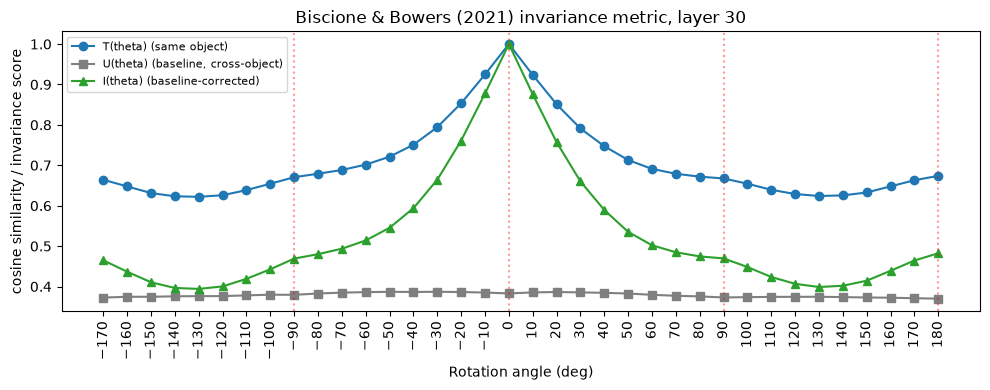

In [16]:
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(biscione_df["angle"], biscione_df["T"], marker="o", color="tab:blue", label="T(theta) (same object)")
ax1.plot(biscione_df["angle"], biscione_df["U"], marker="s", color="tab:gray", label="U(theta) (baseline, cross-object)")
ax1.plot(biscione_df["angle"], biscione_df["I"], marker="^", color="tab:green", label="I(theta) (baseline-corrected)")
for ca in cardinal_angles:
    ax1.axvline(ca, color="red", linestyle=":", alpha=0.4)
ax1.set_xlabel("Rotation angle (deg)")
ax1.set_ylabel("cosine similarity / invariance score")
ax1.set_xticks(angles)
ax1.tick_params(axis="x", rotation=90)
ax1.legend(fontsize=8)
ax1.set_title("Biscione & Bowers (2021) invariance metric, layer 30")
plt.tight_layout()
plt.show()


## 2. Layerwise Invariance Across Transformations

In [17]:
LAYER_INDICES = list(range(31))


def compute_layerwise_invariance(transform: str, param: float, ref_param: float = 0.0) -> pd.DataFrame:
    """Compute per-layer T/U/I for `transform` at `param`, against the reference at `ref_param`."""
    rows = []
    for l in tqdm(LAYER_INDICES, desc=f"Layerwise invariance ({transform}={param})"):
        X0_l = extract_layer_features(l, transform, ref_param)
        Y_l = extract_layer_features(l, transform, param)
        n, c, h, w = X0_l.shape
        d_l = c * h * w

        rng = np.random.default_rng(RANDOM_STATE)
        scores = biscione_invariance(X0_l.reshape(n, d_l), Y_l.reshape(n, d_l), NULL_REPEATS, rng)

        rows.append({"layer": l, "d": d_l, "spatial": f"{c}x{h}x{w}", **scores})

    return pd.DataFrame(rows).sort_values("layer").reset_index(drop=True)


def plot_layerwise_invariance(df: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df["layer"], df["T"], marker="o", color="tab:blue", label="T (same object)")
    ax.plot(df["layer"], df["U"], marker="s", color="tab:gray", label="U (baseline)")
    ax.plot(df["layer"], df["I"], marker="^", color="tab:green", label="I (baseline-corrected)")
    ax.set_xlabel("VGG layer index")
    ax.set_ylabel("cosine similarity / invariance score")
    ax.set_xticks(df["layer"])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


Layerwise invariance (rotation=90): 100%|██████████| 31/31 [03:23<00:00,  6.56s/it]


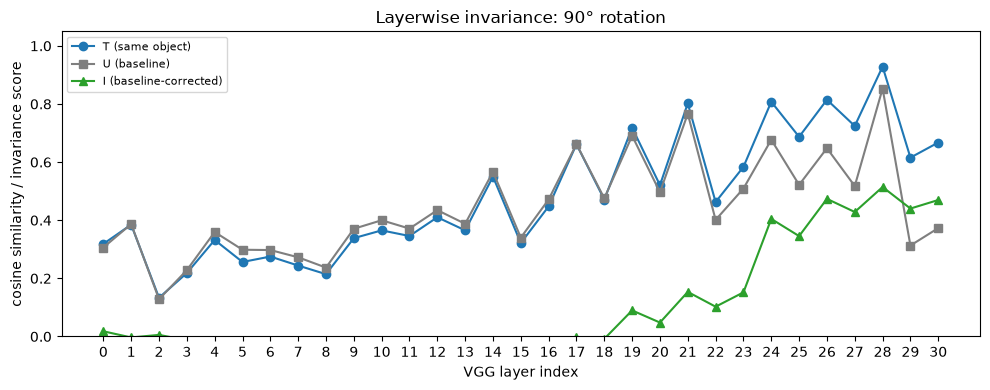

,layer,d,spatial,T,U,I
0,0,65536,64x32x32,0.318658,0.306213,0.017937
1,1,65536,64x32x32,0.384901,0.386930,-0.003311
2,2,65536,64x32x32,0.133205,0.128404,0.005508
3,3,65536,64x32x32,0.218389,0.228273,-0.012808
4,4,16384,64x16x16,0.332084,0.359451,-0.042723
5,5,32768,128x16x16,0.256380,0.298524,-0.060078
6,6,32768,128x16x16,0.275054,0.297456,-0.031887
7,7,32768,128x16x16,0.244066,0.272527,-0.039123
8,8,32768,128x16x16,0.214487,0.237080,-0.029614
9,9,8192,128x8x8,0.338390,0.370666,-0.051285


In [18]:
df_rot90 = compute_layerwise_invariance("rotation", 90)
plot_layerwise_invariance(df_rot90, "Layerwise invariance: 90° rotation")
df_rot90


Layerwise invariance (rotation=180): 100%|██████████| 31/31 [03:19<00:00,  6.44s/it]


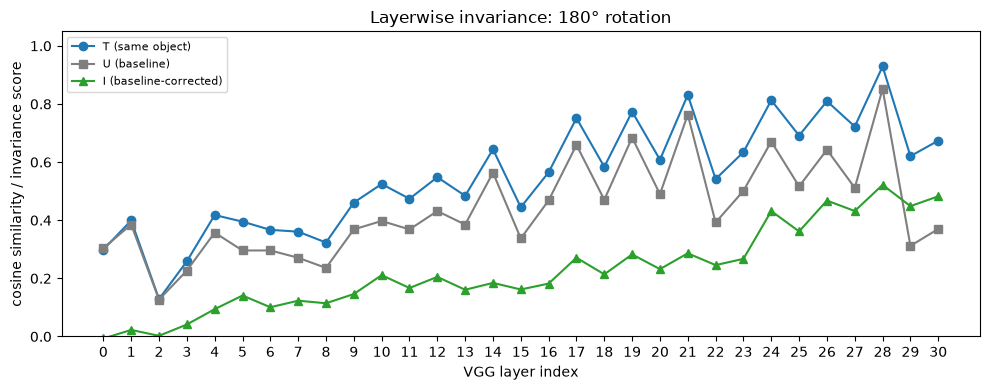

,layer,d,spatial,T,U,I
0,0,65536,64x32x32,0.299183,0.303970,-0.006878
1,1,65536,64x32x32,0.399184,0.385327,0.022544
2,2,65536,64x32x32,0.128807,0.126759,0.002344
3,3,65536,64x32x32,0.258726,0.226789,0.041304
4,4,16384,64x16x16,0.417899,0.357462,0.094059
5,5,32768,128x16x16,0.395223,0.295955,0.140996
6,6,32768,128x16x16,0.366944,0.296077,0.100675
7,7,32768,128x16x16,0.360718,0.270924,0.123161
8,8,32768,128x16x16,0.323325,0.235922,0.114390
9,9,8192,128x8x8,0.460785,0.368522,0.146106


In [19]:
df_rot180 = compute_layerwise_invariance("rotation", 180)
plot_layerwise_invariance(df_rot180, "Layerwise invariance: 180° rotation")
df_rot180


Layerwise invariance (blur=3.0): 100%|██████████| 31/31 [04:00<00:00,  7.75s/it]


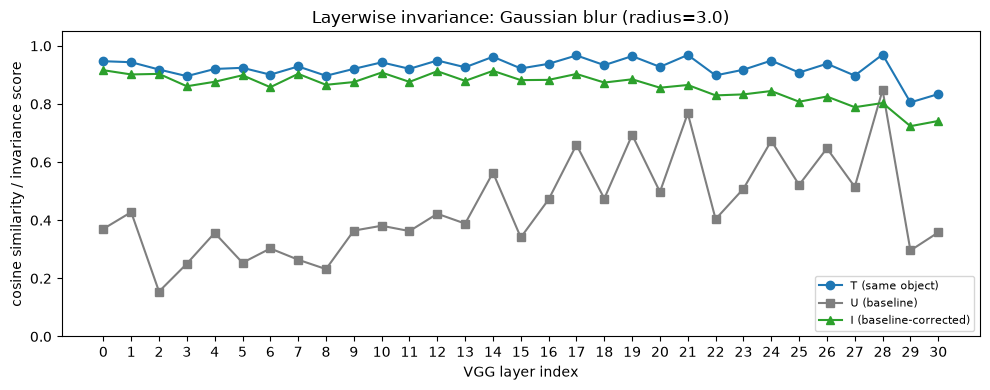

,layer,d,spatial,T,U,I
0,0,65536,64x32x32,0.947252,0.370337,0.916228
1,1,65536,64x32x32,0.943729,0.427870,0.901647
2,2,65536,64x32x32,0.918544,0.154717,0.903634
3,3,65536,64x32x32,0.895825,0.250516,0.861004
4,4,16384,64x16x16,0.920502,0.356436,0.876473
5,5,32768,128x16x16,0.924477,0.253699,0.898804
6,6,32768,128x16x16,0.900896,0.302936,0.857827
7,7,32768,128x16x16,0.929162,0.264178,0.903729
8,8,32768,128x16x16,0.897073,0.231868,0.866003
9,9,8192,128x8x8,0.920831,0.364336,0.875455


In [20]:
df_blur = compute_layerwise_invariance("blur", 3.0)
plot_layerwise_invariance(df_blur, "Layerwise invariance: Gaussian blur (radius=3.0)")
df_blur


Layerwise invariance (scale=0.5): 100%|██████████| 31/31 [03:33<00:00,  6.89s/it]


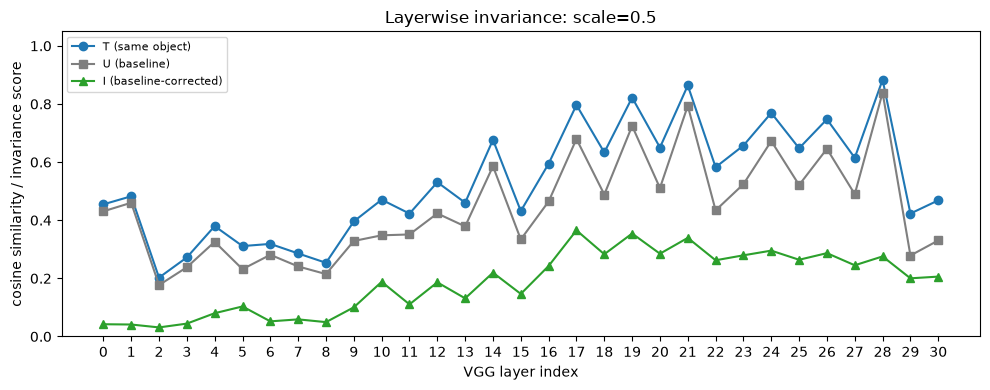

,layer,d,spatial,T,U,I
0,0,65536,64x32x32,0.454737,0.430719,0.042190
1,1,65536,64x32x32,0.482406,0.460156,0.041215
2,2,65536,64x32x32,0.202608,0.176881,0.031256
3,3,65536,64x32x32,0.272061,0.238299,0.044325
4,4,16384,64x16x16,0.379798,0.325767,0.080136
5,5,32768,128x16x16,0.311116,0.231670,0.103401
6,6,32768,128x16x16,0.318588,0.281141,0.052092
7,7,32768,128x16x16,0.285742,0.241009,0.058938
8,8,32768,128x16x16,0.253575,0.214740,0.049455
9,9,8192,128x8x8,0.396107,0.328687,0.100430


In [21]:
df_scale_half = compute_layerwise_invariance("scale", 0.5, ref_param=1.0)
plot_layerwise_invariance(df_scale_half, "Layerwise invariance: scale=0.5")
df_scale_half


Layerwise invariance (scale=1.5): 100%|██████████| 31/31 [04:20<00:00,  8.40s/it]


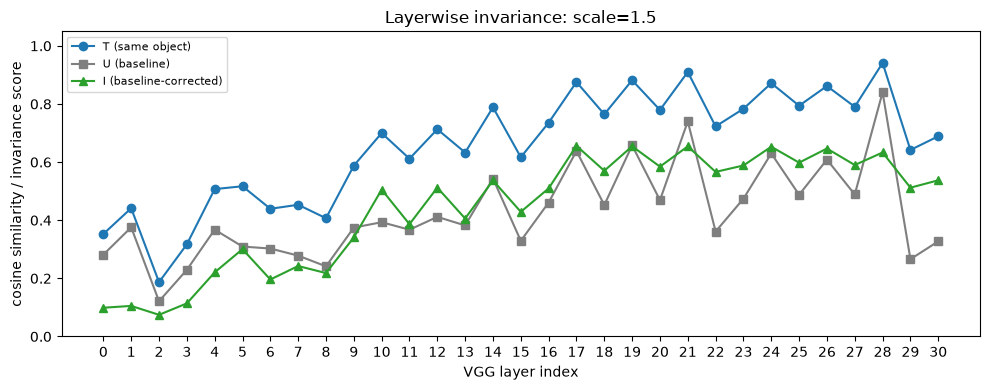

,layer,d,spatial,T,U,I
0,0,65536,64x32x32,0.352747,0.281643,0.098982
1,1,65536,64x32x32,0.441315,0.375611,0.105229
2,2,65536,64x32x32,0.186935,0.121419,0.074570
3,3,65536,64x32x32,0.317205,0.229377,0.113970
4,4,16384,64x16x16,0.507132,0.367604,0.220633
5,5,32768,128x16x16,0.516984,0.309465,0.300519
6,6,32768,128x16x16,0.439445,0.302672,0.196139
7,7,32768,128x16x16,0.453248,0.278212,0.242503
8,8,32768,128x16x16,0.407003,0.241459,0.218240
9,9,8192,128x8x8,0.587893,0.374677,0.340969


In [22]:
df_scale_150 = compute_layerwise_invariance("scale", 1.5, ref_param=1.0)
plot_layerwise_invariance(df_scale_150, "Layerwise invariance: scale=1.5")
df_scale_150


A rising `I` with depth would indicate that later layers increasingly encode invariant representations, consistent with the general expectation that invariance to nuisance transforms builds up over the course of a CNN. This is now evaluated for five transformations - 90° rotation, 180° rotation, Gaussian blur, and scale (0.5, 1.5) - each in its own cell (`df_rot90`, `df_rot180`, `df_blur`, `df_scale_half`, `df_scale_150`), all built from the same `compute_layerwise_invariance`/`plot_layerwise_invariance` helpers. When comparing across transformations, keep the caveat above in mind: absolute `I` values in the early layers are influenced by the shared gray background/aperture and are most informative as a depth *trend*, not in isolation. Since blur and scale do not reassign the orientation channel a filter responds through the way rotation does, they are expected to show a smoother, more monotonic increase in `I` with depth than the two rotation cases. Extending this further (e.g. additional rotation angles, shift, skew) is a small, local addition: reuse `compute_layerwise_invariance` with a new `(transform, param)` pair, adding the corresponding branch to `apply_named_transform` in Section 0 if it is a new transform kind.
